In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [3]:
import os

print(os.getcwd())

C:\Users\Hp\Documents\Predictive-Maintenance-IoT-AI\notebooks


In [6]:
df = pd.read_csv("../data/model_ready_dataset.csv")

In [7]:
df = pd.read_csv("../data/model_ready_dataset.csv")

print(df.shape)
print(df.columns.tolist())

(10000, 21)
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'timestamp', 'Ambient_Temperature', 'Load_Density', 'Humidity', 'Shift', 'Day_Type', 'temp_diff', 'load_ratio', 'humidity_impact', 'Machine failure']


In [8]:
X = df.drop("Machine failure", axis=1)
y = df["Machine failure"]

In [9]:
timestamp = X["timestamp"].copy()

In [10]:
X = X.drop(columns=["timestamp"])

In [11]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in X.select_dtypes(include="object"):
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

In [12]:
X.columns = (
    X.columns
      .str.replace(" ", "_")
      .str.replace("[", "", regex=False)
      .str.replace("]", "", regex=False)
      .str.replace("/", "_")
)

In [13]:
print(X.columns.tolist())

['Type', 'Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Ambient_Temperature', 'Load_Density', 'Humidity', 'Shift', 'Day_Type', 'temp_diff', 'load_ratio', 'humidity_impact']


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [15]:
from lightgbm import LGBMClassifier

model = LGBMClassifier(random_state=42)

model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 271, number of negative: 7729
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001236 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1494
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.033875 -> initscore=-3.350616
[LightGBM] [Info] Start training from score -3.350616
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

baseline_pred = model.predict(X_test)
baseline_prob = model.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, baseline_pred))
print("Precision:", precision_score(y_test, baseline_pred))
print("Recall   :", recall_score(y_test, baseline_pred))
print("F1 Score :", f1_score(y_test, baseline_pred))
print("ROC AUC  :", roc_auc_score(y_test, baseline_prob))

Accuracy : 0.999
Precision: 1.0
Recall   : 0.9705882352941176
F1 Score : 0.9850746268656716
ROC AUC  : 0.990108543417367


In [17]:
X_test_noise = X_test.copy()

In [18]:
numeric_cols = X_test_noise.select_dtypes(include=["int64", "float64"]).columns

print(numeric_cols)

Index(['Type', 'Air_temperature_K', 'Process_temperature_K',
       'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'TWF', 'HDF',
       'PWF', 'OSF', 'RNF', 'Ambient_Temperature', 'Load_Density', 'Humidity',
       'Shift', 'Day_Type', 'temp_diff', 'load_ratio', 'humidity_impact'],
      dtype='str')


In [19]:
import numpy as np

noise_level = 0.05

for col in numeric_cols:

    std = X_test_noise[col].std()

    noise = np.random.normal(
        loc=0,
        scale=std * noise_level,
        size=len(X_test_noise)
    )

    X_test_noise[col] += noise

In [20]:
noise_pred = model.predict(X_test_noise)
noise_prob = model.predict_proba(X_test_noise)[:,1]

In [21]:
print("Accuracy :", accuracy_score(y_test, noise_pred))
print("Precision:", precision_score(y_test, noise_pred))
print("Recall   :", recall_score(y_test, noise_pred))
print("F1 Score :", f1_score(y_test, noise_pred))
print("ROC AUC  :", roc_auc_score(y_test, noise_prob))

Accuracy : 0.1435
Precision: 0.03714124929656725
Recall   : 0.9705882352941176
F1 Score : 0.07154471544715447
ROC AUC  : 0.813911977834612


In [22]:
import pandas as pd

comparison = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],

    "Original": [

        accuracy_score(y_test, baseline_pred),

        precision_score(y_test, baseline_pred),

        recall_score(y_test, baseline_pred),

        f1_score(y_test, baseline_pred),

        roc_auc_score(y_test, baseline_prob)

    ],

    "Noisy": [

        accuracy_score(y_test, noise_pred),

        precision_score(y_test, noise_pred),

        recall_score(y_test, noise_pred),

        f1_score(y_test, noise_pred),

        roc_auc_score(y_test, noise_prob)

    ]

})

comparison

,Metric,Original,Noisy
0,Accuracy,0.999000,0.143500
1,Precision,1.000000,0.037141
2,Recall,0.970588,0.970588
3,F1 Score,0.985075,0.071545
4,ROC AUC,0.990109,0.813912


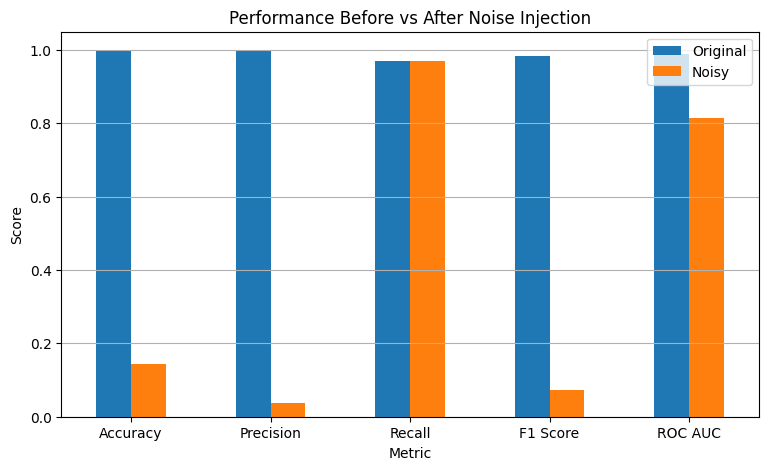

In [23]:
import matplotlib.pyplot as plt

comparison.set_index("Metric").plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Performance Before vs After Noise Injection")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

In [24]:
comparison.to_csv("../reports/noise_sensitivity_results.csv", index=False)